<a href="https://colab.research.google.com/github/MNTech955/100-days-of-machine-learning/blob/main/Outlier__Detection__and__Removal__using_Z_score__Method_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('sample_data/placement.csv')

df.shape
(1000, 3)

df.sample(5)

,Unnamed: 0,cgpa,iq,placement
47,47,5.2,161.0,0
56,56,6.1,65.0,0
53,53,8.3,168.0,1
85,85,5.8,166.0,1
66,66,6.9,96.0,1


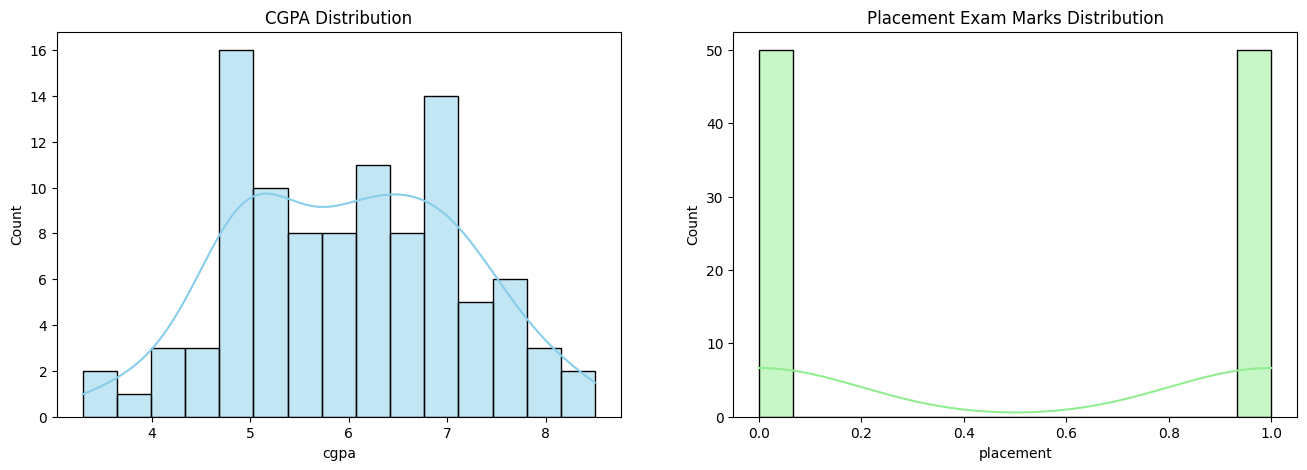

In [9]:
# Columns strip karna
# Ye line dataframe df ke column names ke aas-paas ke extra spaces remove karti hai.
# Kabhi CSV mein extra spaces hoti hain (' placement ' instead of 'placement') → ye error KeyError deta hai.
df.columns = df.columns.str.strip()
# Ye overall figure size set karta hai.
# 16 = width, 5 = height (in inches) → wide layout for side-by-side plots.
plt.figure(figsize=(16,5))

# CGPA ka histogram
# plt.subplot(rows, cols, position) ka matlab hai:
# 1,2 → 1 row aur 2 columns
# 1 → pehla plot (left side)
# Ye plot first subplot ko define karta hai.
plt.subplot(1,2,1)
# sns.histplot() → seaborn ka function histogram plot karne ke liye
# df['cgpa'] → CGPA column ka data
# kde=True → KDE curve (smooth probability curve) bhi draw kare
# bins=15 → histogram ke bins (columns) ka number
# color='skyblue' → bars ka color
sns.histplot(df['cgpa'], kde=True, bins=15, color='skyblue')
plt.title('CGPA Distribution')

# Placement marks ka histogram
plt.subplot(1,2,2)
sns.histplot(df['placement'], kde=True, bins=15, color='lightgreen')
plt.title('Placement Exam Marks Distribution')

plt.tight_layout()
# Figure ko display karta hai
plt.show()
# 💡 Summary:

# Ye code side-by-side histograms create karta hai:
# Left → CGPA distribution
# Right → Placement exam marks distribution
# Har histogram ke upar smooth KDE curve draw hota hai
# Colors, bins aur layout visually appealing hai

In [10]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 5.9910000000000005
Std value of cgpa 1.1436336737775692
Min value of cgpa 3.3
Max value of cgpa 8.5


In [11]:
# Finding the boundary values
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 9.421901021332708
Lowest allowed 2.560098978667293


In [12]:
# Finding the outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,Unnamed: 0,cgpa,iq,placement
7,7,5.0,63.0,0
9,9,5.1,66.0,0
15,15,5.1,176.0,0
17,17,3.3,183.0,0
18,18,4.0,100.0,0
22,22,4.9,120.0,0
23,23,4.7,87.0,0
24,24,4.7,121.0,0
25,25,5.0,91.0,0
31,31,3.9,109.0,0


Trimming

In [13]:
# Trimming

new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
92,92,5.2,110.0,0
93,93,6.8,112.0,1
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [14]:
# Approach 2

# Calculating the Zscore

df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()


In [15]:
df.head()

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore
0,0,6.8,123.0,1,0.707394
1,1,5.9,106.0,0,-0.079571
2,2,5.3,121.0,0,-0.604214
3,3,7.4,132.0,1,1.232038
4,4,5.8,142.0,0,-0.167012


In [16]:
df[df['cgpa_zscore'] > 3]

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore


In [17]:
df[df['cgpa_zscore'] < -3]

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore


In [18]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore


In [19]:
# Trimming
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]
new_df

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore
0,0,6.8,123.0,1,0.707394
1,1,5.9,106.0,0,-0.079571
2,2,5.3,121.0,0,-0.604214
3,3,7.4,132.0,1,1.232038
4,4,5.8,142.0,0,-0.167012
...,...,...,...,...,...
95,95,4.3,200.0,0,-1.478620
96,96,4.4,42.0,0,-1.391180
97,97,6.7,182.0,1,0.619954
98,98,6.3,103.0,1,0.270191


Capping

In [20]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [21]:
lower_limit

np.float64(2.560098978667293)

In [22]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [23]:
df.shape

(100, 5)

In [24]:
df['cgpa'].describe()

,cgpa
count,100.000000
mean,5.991000
std,1.143634
min,3.300000
25%,5.075000
50%,6.000000
75%,6.900000
max,8.500000
